In [1]:
from resources.imports import *
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchinfo import summary
import optuna 

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, GCN, GAT

# GNN Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="GNN")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")     

Using device: cpu


In [4]:
perIN_ = DAT.perIN.reshape(int(len(DAT.perIN)/2), 2)
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [5]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [8, 16, 32]

BATCH_SIZE = 8
LEARNING_RATE = 1e-3

In [6]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.train_inST, DAT.train_outST)]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.val_inST, DAT.val_outST)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.test_inST, DAT.test_outST)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

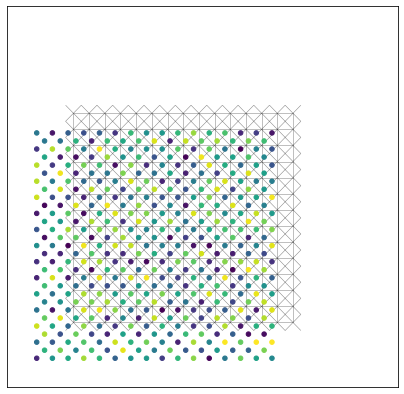

In [7]:
visualize_graphNetwork(train_dataloader, pos=perIN_, colors=None, layout="kk")

In [8]:
GCN1 = MODEL(
    typ="GNN",
    model=GCN(in_size, h_size, out_size, norm="layer", pool="mean").to(device),
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 8, 1e-4, True), 
    earlyStop=EarlyStopping(patience=25, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

GAT1 = MODEL(
    typ="GNN",
    model=GAT(in_size, h_size, out_size, heads=2, norm=None, pool="mean").to(device),
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 8, 1e-4, True), 
    earlyStop=EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

sample_batch = next(iter(train_dataloader)).to(device)
summary(GAT1.model, input_data=(sample_batch.x, edge_index, sample_batch.batch))

c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
GAT                                      [8, 201]                  6,633
├─GATConv: 1-1                           [3600, 16]                48
│    └─Linear: 2-1                       [3600, 16]                32
│    └─SumAggregation: 2-2               [3600, 2, 8]              --
├─Sequential: 1-6                        --                        (recursive)
│    └─ReLU: 2-3                         [3600, 16]                --
├─ModuleList: 1-5                        --                        (recursive)
│    └─gatBlock: 2-4                     [3600, 32]                --
│    │    └─GATConv: 3-1                 [3600, 32]                608
├─Sequential: 1-6                        --                        (recursive)
│    └─ReLU: 2-5                         [3600, 32]                --
├─ModuleList: 1-5                        --                        (recursive)
│    └─gatBlock: 2-6                     [360

Epoch: 1 - Loss: 0.0029316062573343515
Epoch: 10 - Loss: 0.0042527285404503345
Epoch: 20 - Loss: 0.001705040573142469
Epoch: 30 - Loss: 0.0036362900864332914
Epoch: 40 - Loss: 0.00286985095590353
Epoch: 50 - Loss: 0.0051437742076814175
Epoch: 60 - Loss: 0.003450328018516302
Epoch: 70 - Loss: 0.003378021763637662
Epoch: 80 - Loss: 0.0029655159451067448
Early stopping triggered after 50 epochs without improvement.
Best Epoch: 81, with loss 0.0012862766161561012


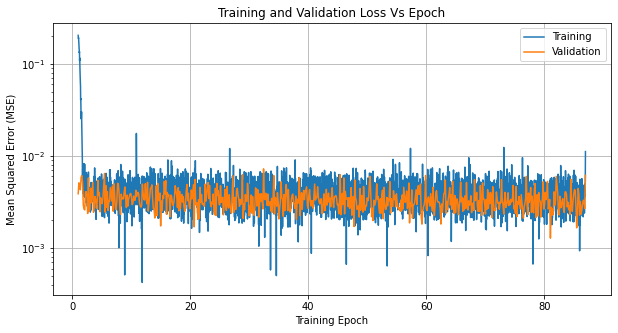

In [22]:
GAT1.train(n_epochs=200, verbose=10, plot=True)

Best prediction: 121, Worst prediction: 37


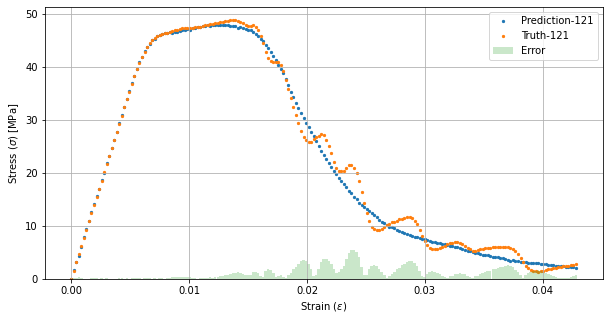

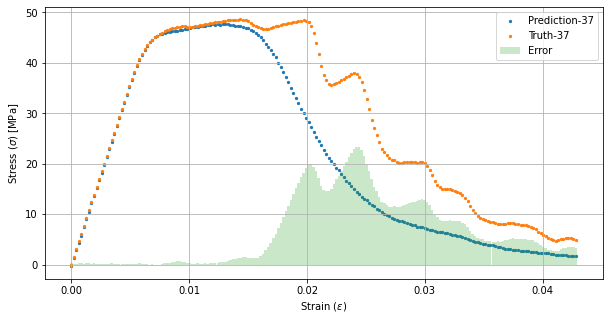

In [23]:
GAT1.predict(stand=True, plot=True)